# Random Forest - Bias & Variance Trade-off [ Regression ]
- Bias (Underfitting): High bias occurs when a model is too simple to capture the underlying patterns of the data. For the circular dataset provided, a linear classifier would have high bias because it cannot represent a circular boundary.

- Variance (Overfitting): High variance occurs when a model "memorizes" the training data rather than learning the general pattern. A single, unpruned Decision Tree often exhibits high variance by creating extremely jagged boundaries to capture every outlier. 

* The goal is to find a balance between low bias and low variance.
* The Random Forest algorithm is specifically designed to navigate this trade-off through Bagging (Bootstrap Aggregating).
   - Reducing Variance: By training multiple decision trees on different subsets of the data and averaging their results, the "noise" captured by individual trees cancels out. This leads to a smoother decision boundary that generalizes better to unseen data.
   - Maintaining Low Bias: Because the individual trees are allowed to grow deep (capturing the complex circular shape), the ensemble retains the ability to model non-linear relationships, keeping bias low.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import r2_score, mean_squared_error

### Dataset Generation

The true function $f(x) = e^{-x^2} + 1.5 \cdot e^{-(x-2)^2}$ produces two overlapping Gaussian peaks over the domain $[-5, 5]$. Gaussian noise is added to the training and test samples to simulate real-world measurement error.

| Split | Samples | Purpose |
|---|---|---|
| Train | 150 | Fit the regressors |
| Test | 1000 | Dense grid for smooth prediction curves |

In [67]:
# Configuration
N_TRAIN = 150
N_TEST  = 1000
NOISE   = 0.1

def f(X):
    """True underlying function: sum of two Gaussian bumps."""
    X = X.ravel()
    return np.exp(-X**2) + 1.5 * np.exp(-(X - 2)**2)

def generate(n_samples, noise):
    """Generate noisy samples from f(x) over [-5, 5]."""
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = f(X) + np.random.normal(0.0, noise, n_samples)
    return X.reshape(n_samples, 1), y

X_train, y_train = generate(N_TRAIN, NOISE)
X_test,  y_test  = generate(N_TEST,  NOISE)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

Train : (150, 1)
Test  : (1000, 1)


In [68]:
X_train ,y_train   = generate(150,0.1)
X_test, y_test  = generate(1000,0.1)

### Visualizing the True Function and Training Data

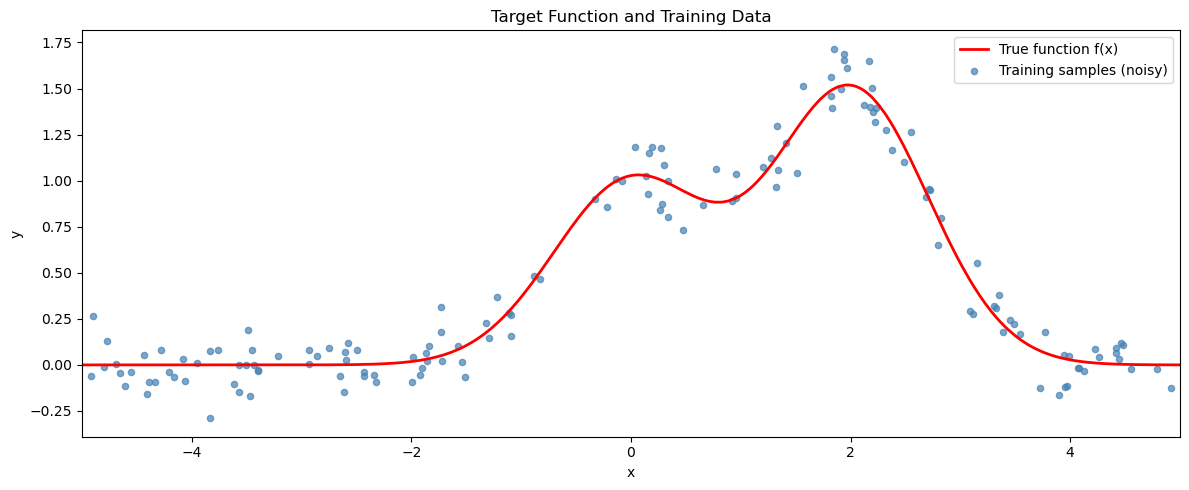

In [70]:
plt.figure(figsize=(12, 5))
plt.plot(X_test, f(X_test), 'r', lw=2, label='True function f(x)')
plt.scatter(X_train, y_train, c='steelblue', s=20, alpha=0.7, label='Training samples (noisy)')
plt.xlim([-5, 5])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Target Function and Training Data')
plt.legend()
plt.tight_layout()
plt.show()

## Decision Tree Without Random Forest
Baseline: Single Decision Tree Regressor

A single `DecisionTreeRegressor` with no depth constraint fits the training data by learning axis-aligned step functions. On dense test data this produces a jagged, overfitted prediction curve — the tree memorizes the training noise rather than the underlying smooth signal.

In [72]:
decision_tree  =  DecisionTreeRegressor()
decision_tree.fit(X_train,y_train)
y_pred = decision_tree.predict(X_test)

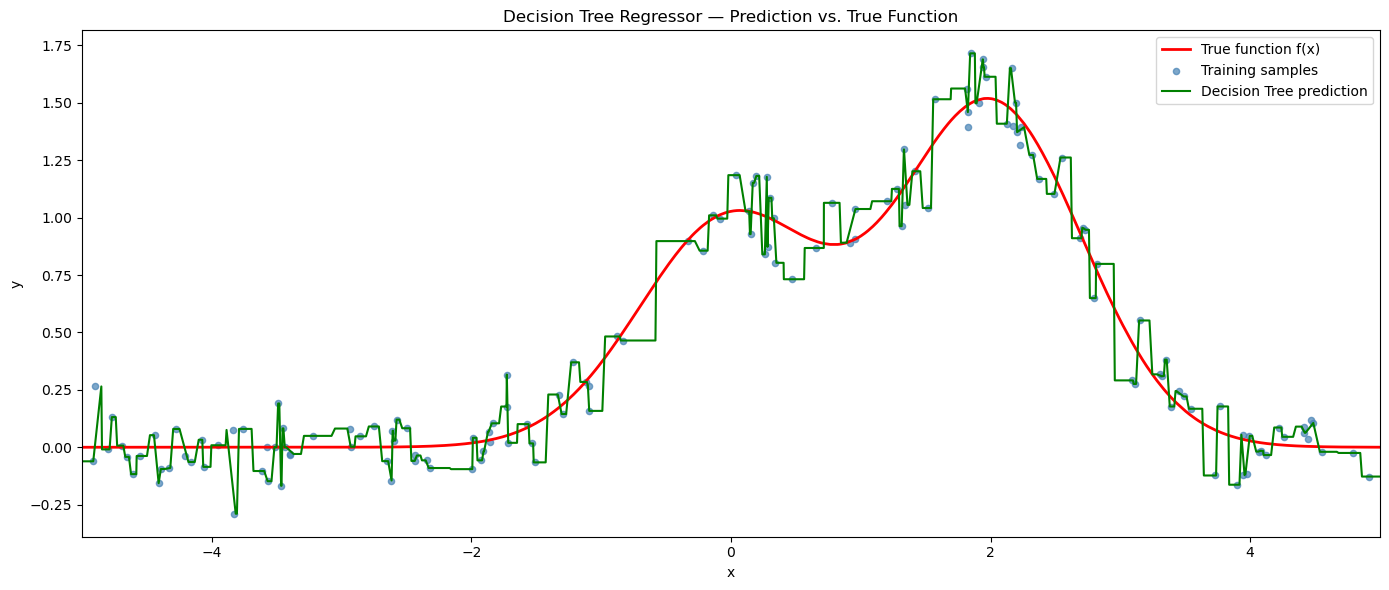

In [73]:
plt.figure(figsize=(14,6))
plt.plot(X_test, f(X_test), 'r', lw=2, label='True function f(x)')
plt.scatter(X_train, y_train, c='steelblue', s=20, alpha=0.7, label='Training samples')
plt.plot(X_test, y_pred, 'g', lw=1.5, label='Decision Tree prediction')
plt.xlim([-5, 5])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Decision Tree Regressor — Prediction vs. True Function')
plt.legend()
plt.tight_layout()
plt.show()

### Decision Tree With Random Forest
Random Forest Regressor

A `RandomForestRegressor` with 1000 trees averages the predictions of 1000 independently trained decision trees, each built on a different bootstrap sample and random feature subset. The averaging smooths out the jagged step-function artifacts and produces a prediction curve that tracks the true function much more closely.

In [75]:
random_forest = RandomForestRegressor(n_estimators=1000)
random_forest.fit(X_train,y_train)
y_pred_rf = random_forest.predict(X_test) 

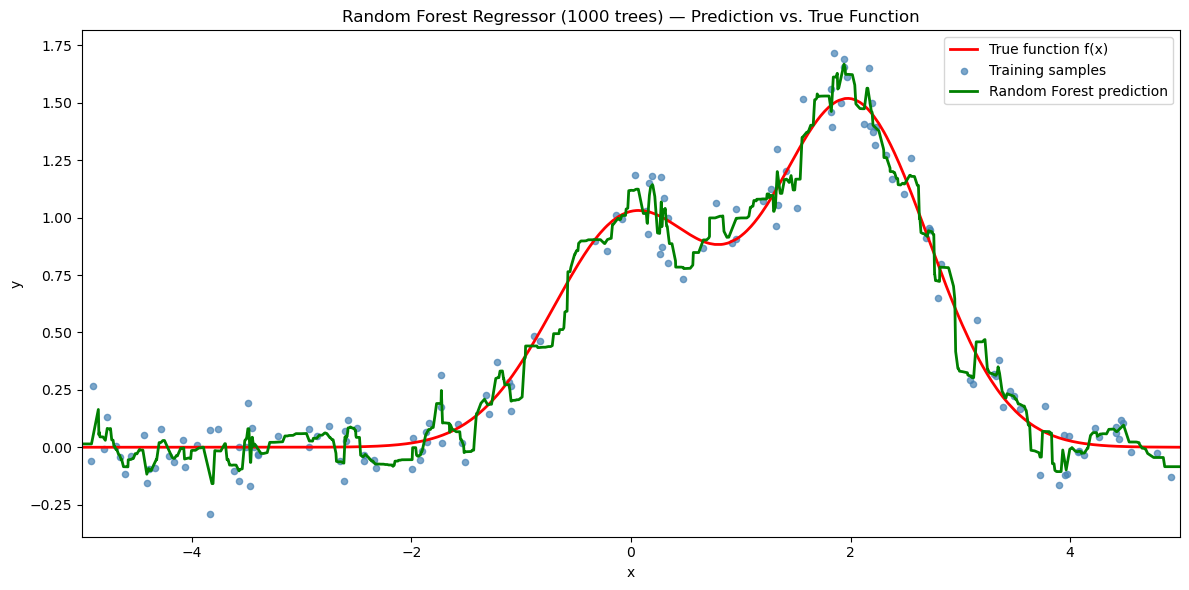

In [76]:
plt.figure(figsize=(12,6))
plt.plot(X_test, f(X_test), 'r', lw=2, label='True function f(x)')
plt.scatter(X_train, y_train, c='steelblue', s=20, alpha=0.7, label='Training samples')
plt.plot(X_test, y_pred_rf, 'g', lw=2, label='Random Forest prediction')
plt.xlim([-5, 5])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Random Forest Regressor (1000 trees) — Prediction vs. True Function')
plt.legend()
plt.tight_layout()
plt.show()

### Results 

In [104]:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest (1000 trees)'],
    'R²': [r2_score(y_test, y_pred), r2_score(y_test, y_pred_rf)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred)),np.sqrt(mean_squared_error(y_test, y_pred_rf))]})

print(results.to_string(index=False))

                     Model       R²     RMSE
             Decision Tree 0.911438 0.150614
Random Forest (1000 trees) 0.937311 0.126717
